# Real Data Examples

In [ ]:
import importlib
import subprocess

def install_if_missing(package, import_name=None):
    name = import_name or package
    if importlib.util.find_spec(name) is None:
        subprocess.run(["pip", "install", package], check=True)

In [2]:

import os
import sys
import torch
import time

from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.insert(0, '/content/drive/My Drive/Colab Notebooks/WGF')

from pathlib import Path
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
import argparse
import torch.nn as nn
import torch.optim as optim
import numpy as np
from matplotlib import pyplot as plt
from sklearn.metrics import mean_squared_error
from scipy.spatial.distance import cdist, pdist
import pandas as pd
import seaborn as sns
from joblib import Parallel, delayed
from tqdm import tqdm
import pickle
import traceback
install_if_missing("pyreadr")
import pyreadr
from flowgem import sample_flowgem
from sklearn.impute import KNNImputer
import itertools

from scipy.optimize import minimize
from scipy.stats import multivariate_normal

install_if_missing("hyperimpute")
from hyperimpute.plugins.imputers import Imputers
import scipy

#sys.path.append(str(Path("MIRI-Imputation").resolve()))
base_path = "/content/drive/My Drive/Colab Notebooks/WGF"
sys.path.append(str(Path(f"{base_path}/MIRI-Imputation").resolve()))
from src.imputer_wrapper import impute_now

Mounted at /content/drive


## Set parameters and load existing results if available

In [3]:
### SETTINGS ###

datasets = ["parkinsons", "allergens", "concrete", "windspeed", "forest", "housing", "stock", "pumadyn32nm", "scm20d", "scm1d"] #

# datasets = ["concrete", "stock", "windspeed", "forest", "housing"]#

# methods = ["flowgem", "mice", "knn", "hyperimpute", "gain", 'miri', 'bayes'] #
methods = ['missdiff']

## Resampling params (still relevant)
param_vals = {
    "ratio": 0.6,
    "n_runs": 1, # more than 1 not implemented (yet)
    "init": "mice",
    "T": 1000,
    "eta": 0.01
}

In [4]:
# install R packages if necessary
if 'bayes' in methods:
    os.environ['RENV_CONFIG_AUTOLOAD_ENABLED'] = 'FALSE'
    os.environ['R_PROFILE_USER'] = ''
    import rpy2.robjects as ro
    from rpy2.robjects import pandas2ri
    from rpy2.robjects.packages import importr
    from rpy2.robjects.conversion import localconverter

    !apt-get install -y r-cran-mcmcpack
    !apt-get install -y r-cran-rfast

    !apt-get install -y r-cran-mcmcpack
    !apt-get install -y r-cran-rfast

    ro.r('''
        packages <- c("mvtnorm", "Rfast")
        for (pkg in packages) {
            if (!requireNamespace(pkg, quietly = TRUE)) {
                install.packages(pkg, repos="https://cloud.r-project.org")
            }
        }
    ''')

    ro.r(f'''
        source("{base_path}/Bayesian/Density_Estimation_Final.R")
        source("{base_path}/Bayesian/MHAlgorithm.R")
        source("{base_path}/Bayesian/helper.R")
    ''')

In [5]:
# Define the log file path
save_dir = f"{base_path}/results"
log_file = os.path.join(save_dir, 'parameter_log.csv')

# Check if the log file exists and read it
if os.path.exists(log_file):
    param_log = pd.read_csv(log_file)
else:
    param_log = pd.DataFrame(columns=['ID', 'dataset', 'method', 'ratio', 'n_runs', 'init', 'T', 'eta'])

# Determine the next ID
this_id = 1 if param_log.empty else param_log['ID'].max() + 1

# Check which datasets and methods already exist for this setup
query_str = " & ".join([f"{k} == {repr(v)}" for k, v in param_vals.items()])
matching = param_log.query(query_str)

needed = pd.DataFrame(itertools.product(datasets, methods), columns=['dataset', 'method'])
done = matching[['dataset', 'method']]
merged = needed.merge(done, how='left', indicator=True)
to_run = list(merged[merged['_merge'] == 'left_only'][['dataset', 'method']].itertuples(index=False, name=None))
to_skip = list(merged[merged['_merge'] == 'both'][['dataset', 'method']].itertuples(index=False, name=None))

if matching.empty:
  results = {"data": {}, "metrics": {}, "Xhat_store": {}}
else:
  results = torch.load(os.path.join(save_dir, f"results_{matching['ID'].iloc[0]}.pt"), weights_only=False)
  this_id = matching['ID'].iloc[0]

for dataset, method in to_skip:
    print(f"[SKIP] {dataset} / {method} already run (ID={matching['ID'].iloc[0]})")

for dataset, method in to_run:
    print(f"[RUN]  {dataset} / {method}")
    new_row = {'ID': this_id, 'dataset': dataset, 'method': method, **param_vals}
    param_log = pd.concat([param_log, pd.DataFrame([new_row])], ignore_index=True)

[RUN]  parkinsons / missdiff
[RUN]  allergens / missdiff
[RUN]  concrete / missdiff
[RUN]  windspeed / missdiff
[RUN]  forest / missdiff
[RUN]  housing / missdiff
[RUN]  stock / missdiff
[RUN]  pumadyn32nm / missdiff
[RUN]  scm20d / missdiff
[RUN]  scm1d / missdiff


## Define functions and load datasets

In [6]:
def impute_bootstrap_per_col(X, M):
    n, d = X.shape
    for j in range(d):
        observed_mask = M[:, j] == 1
        missing_mask = M[:, j] == 0

        observed_values = X[observed_mask, j]
        if observed_values.numel() == 0:
            raise ValueError(f"Value of column {j} is always missing. Need to be observed at least once.")

        num_missing = missing_mask.sum()
        if num_missing > 0:
            rand_idx = torch.randint(0, observed_values.shape[0], (num_missing,), device=X.device)
            X[missing_mask, j] = observed_values[rand_idx]


def energy_distance(X, Y, scale):
    if scale:
        X_np = np.array(X)
        Y_np = np.array(Y)
        center = np.nanmean(X_np, axis=0)
        scl = np.nanstd(X_np, axis=0, ddof=1)

        X = (X_np - center) / scl

        # Scale imputed data using original data's mean and std
        Y = (Y_np - center) / scl

    XY = cdist(X, Y)
    XX = cdist(X, X)
    YY = cdist(Y, Y)
    return (2 * XY.mean() - XX.mean() - YY.mean()) * X.shape[0] / 2

def energy_distance_faster(X, Y, scale):
    if torch.max(torch.abs(X)).item() > 1e100 and torch.max(torch.abs(Y)).item() < 1e100:
        return torch.inf
    if scale:
        X_np = np.array(X)
        Y_np = np.array(Y)
        center = np.nanmean(X_np, axis=0)
        scl = np.nanstd(X_np, axis=0, ddof=1)

        X = (X_np - center) / scl

        # Scale imputed data using original data's mean and std
        Y = (Y_np - center) / scl

    n = X.shape[0]
    xx_mean = pdist(X).sum() * 2 / (n * n)   # divide by n^2 to match cdist mean
    yy_mean = pdist(Y).sum() * 2 / (n * n)   # same for Y
    xy_mean = cdist(X, Y).mean()

    return (2 * xy_mean - xx_mean - yy_mean) * n / 2

def energy_distance_fixed_X(X, XX_mean, Y):
    XY_mean = cdist(X, Y).mean()
    n = len(Y)
    YY_mean = pdist(Y).mean() * (n - 1) / n
    return 2 * XY_mean - XX_mean - YY_mean

In [7]:
for dataset in datasets:
    if dataset not in results["data"].keys():
        results["data"][dataset] = {}
        results["metrics"][dataset] = {}
        results["Xhat_store"][dataset] = {}
    for run in range(param_vals["n_runs"]):
        torch.manual_seed(run + param_vals["n_runs"])
        np.random.seed(run + param_vals["n_runs"])

        Xstar_df = pyreadr.read_r(f"{base_path}/data/datasets/split/test.{param_vals["ratio"]}.1.{dataset}.RDS")[None]
        X_miss_df = pyreadr.read_r(f"{base_path}/results/amputedsplit/mar.{param_vals["ratio"]}.1.{dataset}.RDS")[None]
        ## M=1-M in the paper
        M_np = (X_miss_df.notna()).astype(int).values
        M_tensor = torch.tensor(M_np, dtype=torch.float64)
        X0_tensor = torch.tensor(X_miss_df.values, dtype=torch.float64)

        if param_vals["init"] == "ColBT":
            # bootstrap imputation
            impute_bootstrap_per_col(X0_tensor, M_tensor) # modifies X0 in-place

            # standardize X0 using observed values only
            Xmiss_tensor = torch.tensor(X_miss_df.values, dtype=torch.float64)
            col_std = torch.nanmean((Xmiss_tensor - torch.nanmean(Xmiss_tensor, dim=0)) ** 2, dim=0) ** 0.5
            col_mean = torch.nanmean(Xmiss_tensor, dim=0)

        elif param_vals["init"] == "mice":
            # Use mice imputation with 10 iterations as X0
            Xmiss_tensor = torch.tensor(X_miss_df.values, dtype=torch.float64)

            col_std = torch.nanmean((Xmiss_tensor - torch.nanmean(Xmiss_tensor, dim=0)) ** 2, dim=0) ** 0.5
            col_mean = torch.nanmean(Xmiss_tensor, dim=0)

            imputer = Imputers().get("mice", max_iter=10)
            df = imputer.fit_transform(X_miss_df)
            X0_np = df.values
            X0_tensor = torch.tensor(X0_np, dtype=torch.float64)

            print(np.isnan(X0_np).any())

        else:
            raise NotImplementedError("This initialization technique is not implemented (yet).")

        X0_std = (X0_tensor - col_mean) / col_std

        # Standardize Xstar (to pass to miri method)
        Xstar_tensor = torch.tensor(Xstar_df.values, dtype=torch.float64)
        Xstar_std = (Xstar_tensor - torch.mean(Xstar_tensor, dim=0)) / torch.std(Xstar_tensor, dim=0)
        results["data"][dataset][run] = {
            "Xstar": Xstar_df,
            "X_miss": X_miss_df,
            "M": M_tensor,
            "X0": X0_tensor,
            "X0_std": X0_std,
            "Xstar_std": Xstar_std,
            "unstd": (lambda X_tens, m=col_mean, s=col_std: X_tens * s + m)

        }

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


False


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


False


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


...

False


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


False


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


False


## Run imputation methods and compute metrics (only those that are not available yet)

In [8]:
for dataset, method in to_run:
    print(f"Running {method} on {dataset}")
    results["metrics"][dataset][method] = []

    for run, run_data in results["data"][dataset].items():
        torch.manual_seed(1)
        np.random.seed(1)

        if method in ["miri", "missdiff", "knewimp"]:
            start = time.time()
            Xhat = impute_now(run_data["X0_std"], run_data["M"], run_data["Xstar_std"], method, max_rounds=15, batchsize=500, maxepochs=900, odesteps=100)[0] ##Setting of images that fits together with learning rate
            runtime = time.time() - start
            Xhats = [run_data["unstd"](Xhat)]

        elif method in ["gain", "knn", "hyperimpute", "mice"]:
            if method == "knn":
                imputer = KNNImputer(n_neighbors=5)
            else:
                imputer = Imputers().get(method)
            start = time.time()
            X_imp = imputer.fit_transform(run_data["X_miss"].values)
            runtime = time.time() - start
            Xhats = [torch.tensor(np.array(X_imp), dtype=torch.float64)]

        elif method == "flowgem":
            start = time.time()
            Xhats = sample_flowgem(run_data["X0_std"], run_data["X0_std"], run_data["M"], T=param_vals["T"], eta=param_vals["eta"], grad_tol=0.01)
            runtime = time.time() - start
            Xhats = [run_data["unstd"](torch.tensor(Xhat, dtype=torch.float64)) for Xhat in Xhats]

        elif method == "bayes":
            ro.r("set.seed(123)")

            # Convert pandas -> R
            X_df = run_data["X_miss"].copy()
            X_df.columns = [f"x{i}" for i in range(X_df.shape[1])]
            with localconverter(ro.default_converter + pandas2ri.converter):
                r_df = ro.conversion.py2rpy(X_df)

            d = X_df.shape[1]
            n = X_df.shape[0]

            dp_gmm = ro.globalenv['dp_gmm_shared_Sigma']
            sample_pp = ro.globalenv['sample_posterior_predictive']

            start = time.time()
            tmp = dp_gmm(
                X=r_df,
                mu0=ro.FloatVector([0] * d),
                tau0_sq=d+1,
                nu0=d+2,
                Psi0=ro.r['diag'](d),
                niter= 800,
                nburn= 300
            )
            r_Xhats = sample_pp(tmp, n_pred=n)
            runtime = time.time() - start

            with localconverter(ro.default_converter + pandas2ri.converter):
                completed_df = ro.conversion.rpy2py(r_Xhats)

            X_imputed = torch.tensor(completed_df, dtype=torch.float64)
            Xhats = [X_imputed]

        else:
            raise NotImplementedError("Method not implemented so far.")

        Xhats_arr = Xhats[-1].detach().cpu().numpy() if isinstance(Xhats[-1], torch.Tensor) else np.array(Xhats[-1])
        Xhats_df = pd.DataFrame(Xhats_arr.astype(np.float64))
        pyreadr.write_rds(f"{base_path}/results/imputations{method}{param_vals["ratio"]}.{dataset}.RDS", Xhats_df)

        Xstar_tensor = torch.tensor(run_data["Xstar"].values, dtype=torch.float64)

        Xid = f"{method}_{dataset}_{run}"
        results["Xhat_store"][dataset][Xid] = Xhats[-1]

        for i, Xhat in enumerate(Xhats):
            results["metrics"][dataset][method].append({
                "run": run,
                "iter": i,
                "energy": energy_distance_faster(Xstar_tensor, Xhat, scale=False),
                "energy.std": energy_distance_faster(Xstar_tensor, Xhat, scale=True)
            })

        results["metrics"][dataset][method][-1]["Xhat_id"] = Xid
        results["metrics"][dataset][method][-1]["runtime"] = runtime

Running missdiff on parkinsons
Training MissDiff model with 100 epochs and 100 diffusion steps...
Training MissDiff model for 100 epochs...


 11%|█         | 11/100 [00:01<00:10,  8.28it/s]

Epoch 10/100, Loss: 0.759246


 21%|██        | 21/100 [00:02<00:09,  8.25it/s]

Epoch 20/100, Loss: 0.714348


...

amount of updates: 0.6302024902416965


100%|██████████| 5/5 [00:04<00:00,  1.04it/s]


amount of updates: 0.6317345603208723


100%|██████████| 5/5 [00:03<00:00,  1.26it/s]


amount of updates: 0.6468220608174075


## Save the results

In [9]:
os.makedirs(save_dir, exist_ok=True)

# filename = f"results.{'.'.join(datasets)}.{'.'.join(methods)}.{ratio}.pt"
filename = f"results_{this_id}.pt"
for dataset in datasets:
   for run in range(param_vals["n_runs"]):
       results["data"][dataset][run].pop("unstd")
torch.save(results, f"{save_dir}/{filename}")

# Save the updated log file
param_log.to_csv(log_file, index=False)

## Analyze the results

In [10]:
for dataset in datasets:
    print(f"----- {dataset} -----")
    for method in methods:
        print(f"{method:<13s}: {results["metrics"][dataset][method][-1]["energy.std"]:.2f}")

----- parkinsons -----
missdiff     : 44.99
----- allergens -----
missdiff     : 89.17
----- concrete -----
missdiff     : 20.21
----- windspeed -----
missdiff     : 2.77
----- forest -----
missdiff     : 4.33
----- housing -----
missdiff     : 13.31
----- stock -----
missdiff     : 7.28
----- pumadyn32nm -----
missdiff     : 230.36
----- scm20d -----
missdiff     : 226.51
----- scm1d -----
missdiff     : 457.23


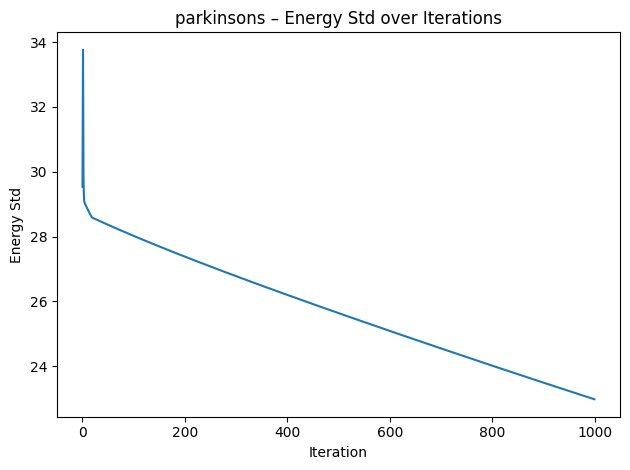

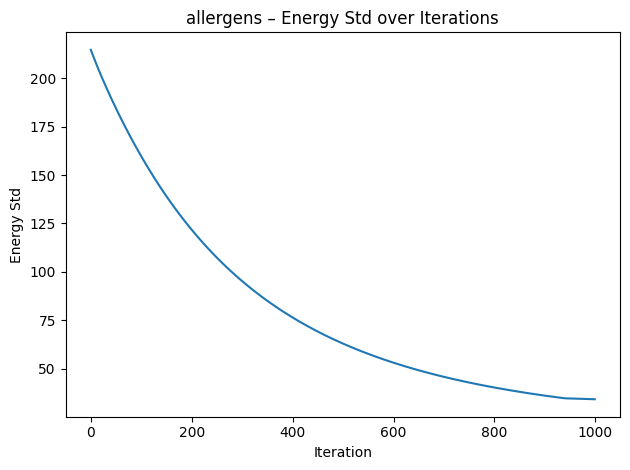

KeyError: 'flowgem'

In [11]:
import matplotlib.pyplot as plt

for dataset in datasets:
    metrics = results["metrics"][dataset]["flowgem"]

    iters = [entry['iter'] for entry in metrics]
    stds  = [entry['energy.std'] for entry in metrics]

    plt.plot(iters, stds)
    plt.xlabel("Iteration")
    plt.ylabel("Energy Std")
    plt.title(f"{dataset} – Energy Std over Iterations")
    plt.tight_layout()
    plt.show()

In [ ]:
save_dir = f"{base_path}/results"
results = torch.load(f"{save_dir}/results_10.pt", weights_only=False)

In [ ]:
results["metrics"].keys()

In [ ]:
results["metrics"]["scm20d"].keys()